<a href="https://colab.research.google.com/github/ditongg/SistemMultimediaWatermarking/blob/main/watermarking_18224026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Watermarking
### Sinyal & Multimedia
<small>M.B. Adyanti Narandita | 18224026</small>


## Cell 1 - Import Library

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
import os
from google.colab import files

print('Semua library berhasil diimport')

Semua library berhasil diimport


## Cell 2 - Load Gambar

Saving watermark.jpg to watermark.jpg
Ukuran gambar: (600, 800)


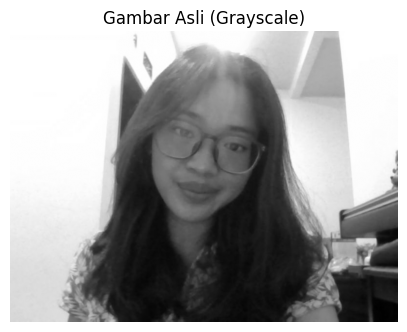

In [2]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = Image.open(filename).convert('L')
img_array = np.array(img, dtype=np.uint8)
print(f'Ukuran gambar: {img_array.shape}')

plt.figure(figsize=(5, 5))
plt.imshow(img_array, cmap='gray')
plt.title('Gambar Asli (Grayscale)')
plt.axis('off')
plt.show()

## Cell 3 - Buat Watermark Biner

Watermark shape: (64, 64)
Contoh nilai baris pertama: [0 1 0 0 0 1 0 0]


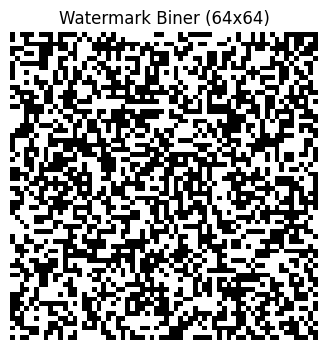

In [3]:
np.random.seed(42)
WM_SIZE = 64
watermark = np.random.randint(0, 2, size=(WM_SIZE, WM_SIZE))
print(f'Watermark shape: {watermark.shape}')
print(f'Contoh nilai baris pertama: {watermark[0, :8]}')

plt.figure(figsize=(4, 4))
plt.imshow(watermark, cmap='gray')
plt.title('Watermark Biner (64x64)')
plt.axis('off')
plt.show()

## Cell 4 - Embed Watermark (LSB)

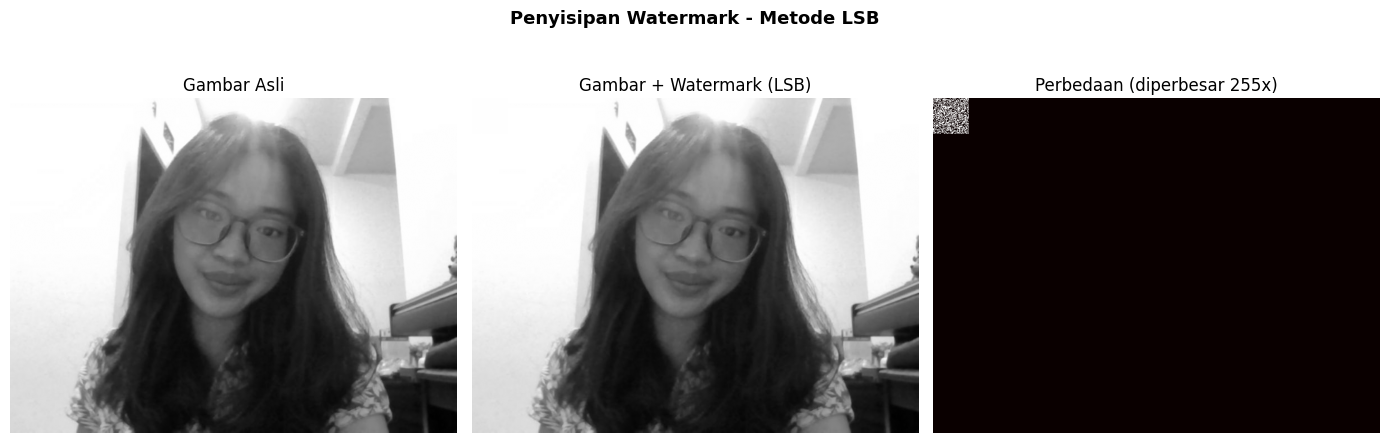

Perbedaan max antar pixel: 1 (tidak terlihat mata)


In [4]:
img_wm = img_array.copy()
img_wm[:WM_SIZE, :WM_SIZE] = (img_wm[:WM_SIZE, :WM_SIZE] & 0b11111110) | watermark
img_wm_pil = Image.fromarray(img_wm)
img_wm_pil.save('wajah_watermarked.png')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

axes[1].imshow(img_wm, cmap='gray')
axes[1].set_title('Gambar + Watermark (LSB)')
axes[1].axis('off')

diff = np.abs(img_array.astype(int) - img_wm.astype(int))
axes[2].imshow(diff * 255, cmap='hot')
axes[2].set_title('Perbedaan (diperbesar 255x)')
axes[2].axis('off')

plt.suptitle('Penyisipan Watermark - Metode LSB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Perbedaan max antar pixel:', diff.max(), '(tidak terlihat mata)')

## Cell 5 - Visualisasi DCT & Quantization

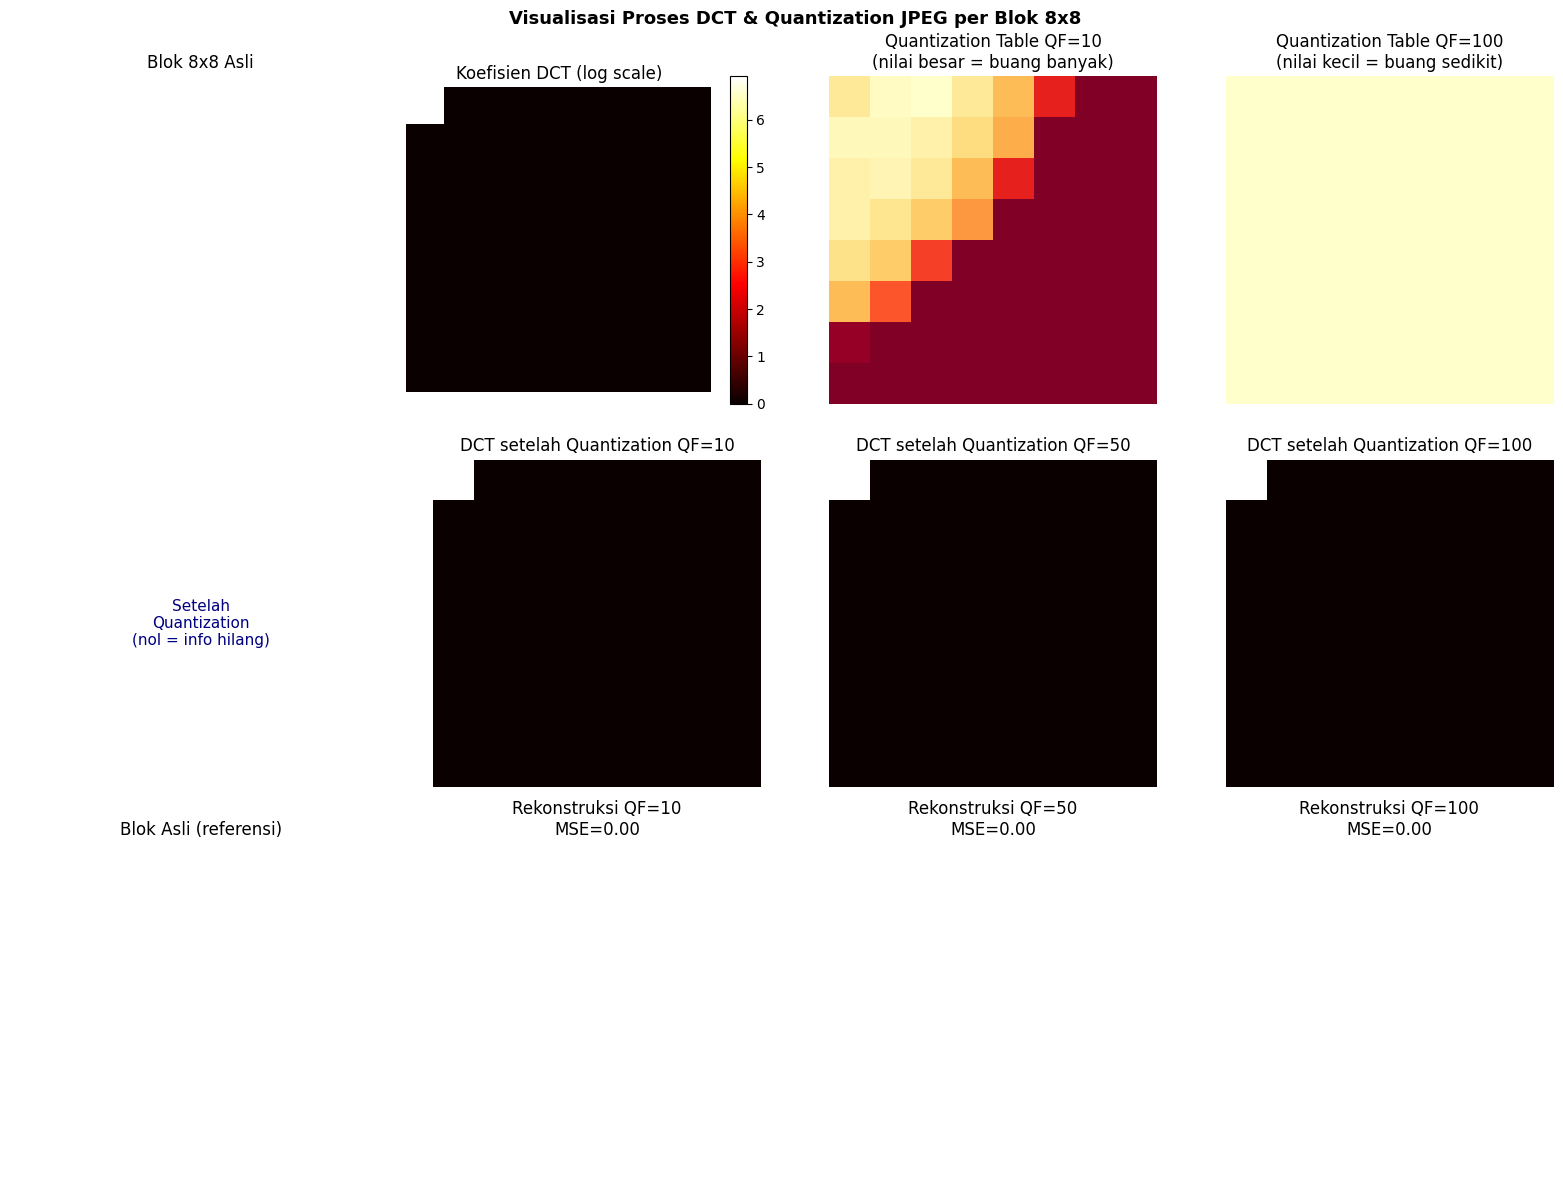

In [5]:
block = img_array[:8, :8].astype(float) - 128

def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

def make_quantization_table(qf):
    base_table = np.array([
        [16,11,10,16,24,40,51,61],
        [12,12,14,19,26,58,60,55],
        [14,13,16,24,40,57,69,56],
        [14,17,22,29,51,87,80,62],
        [18,22,37,56,68,109,103,77],
        [24,35,55,64,81,104,113,92],
        [49,64,78,87,103,121,120,101],
        [72,92,95,98,112,100,103,99]
    ], dtype=float)
    scale = 5000 / qf if qf < 50 else 200 - 2 * qf
    table = np.floor((base_table * scale + 50) / 100)
    return np.clip(table, 1, 255)

dct_block = dct2(block)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Visualisasi Proses DCT & Quantization JPEG per Blok 8x8', fontsize=13, fontweight='bold')

axes[0, 0].imshow(block + 128, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Blok 8x8 Asli')
axes[0, 0].axis('off')

im = axes[0, 1].imshow(np.log(np.abs(dct_block) + 1), cmap='hot')
axes[0, 1].set_title('Koefisien DCT (log scale)')
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1])

axes[0, 2].imshow(make_quantization_table(10), cmap='YlOrRd')
axes[0, 2].set_title('Quantization Table QF=10\n(nilai besar = buang banyak)')
axes[0, 2].axis('off')

axes[0, 3].imshow(make_quantization_table(100), cmap='YlOrRd')
axes[0, 3].set_title('Quantization Table QF=100\n(nilai kecil = buang sedikit)')
axes[0, 3].axis('off')

axes[1, 0].axis('off')
axes[1, 0].text(0.5, 0.5, 'Setelah\nQuantization\n(nol = info hilang)',
                ha='center', va='center', fontsize=11, color='navy',
                transform=axes[1, 0].transAxes)

for col, qf in enumerate([10, 50, 100]):
    qtable = make_quantization_table(qf)
    quantized = np.round(dct_block / qtable)
    axes[1, col+1].imshow(np.abs(quantized), cmap='hot')
    axes[1, col+1].set_title(f'DCT setelah Quantization QF={qf}')
    axes[1, col+1].axis('off')

axes[2, 0].imshow(block + 128, cmap='gray', vmin=0, vmax=255)
axes[2, 0].set_title('Blok Asli (referensi)')
axes[2, 0].axis('off')

for col, qf in enumerate([10, 50, 100]):
    qtable = make_quantization_table(qf)
    quantized = np.round(dct_block / qtable)
    reconstructed = np.clip(idct2(quantized * qtable) + 128, 0, 255)
    mse = np.mean((block + 128 - reconstructed) ** 2)
    axes[2, col+1].imshow(reconstructed, cmap='gray', vmin=0, vmax=255)
    axes[2, col+1].set_title(f'Rekonstruksi QF={qf}\nMSE={mse:.2f}')
    axes[2, col+1].axis('off')

plt.tight_layout()
plt.savefig('visualisasi_dct.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 - Kompresi JPEG Berbagai Quality Factor

QF     Ukuran File     Rasio Kompresi
----------------------------------------
QF=10   8.8 KB          14.2x lebih kecil
QF=20   11.4 KB          10.9x lebih kecil
QF=30   13.7 KB          9.1x lebih kecil
QF=50   16.5 KB          7.5x lebih kecil
QF=70   26.4 KB          4.7x lebih kecil
QF=90   38.4 KB          3.2x lebih kecil
QF=100  93.6 KB          1.3x lebih kecil


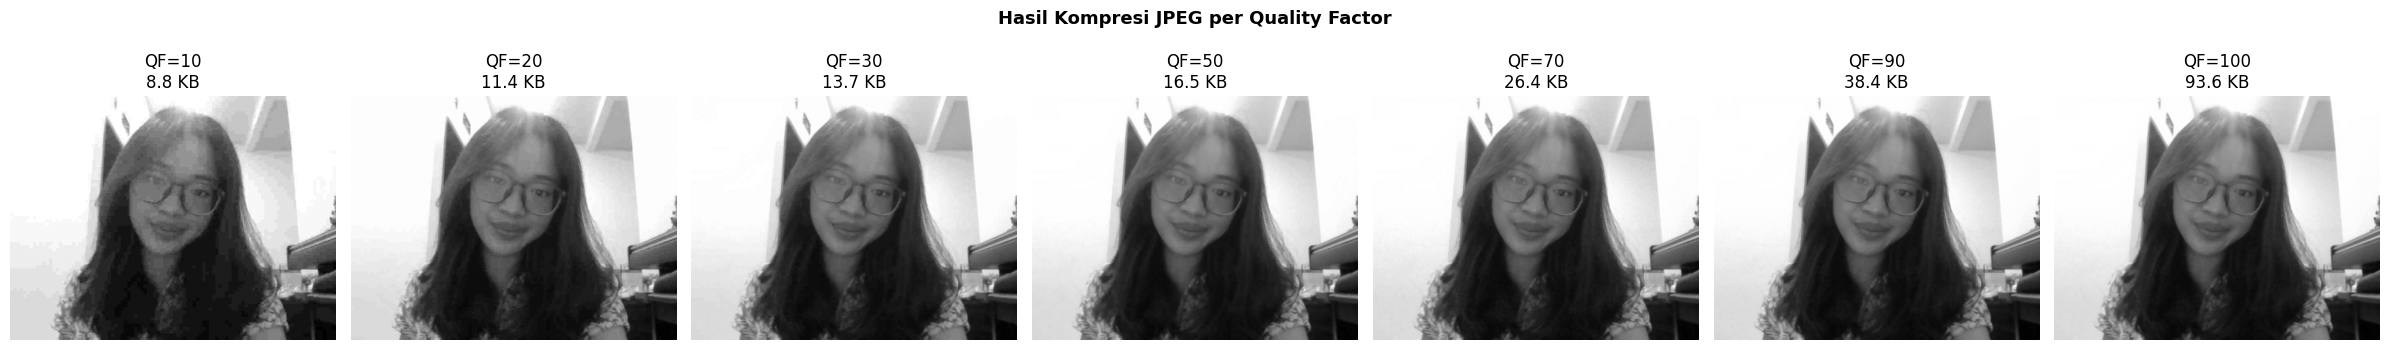

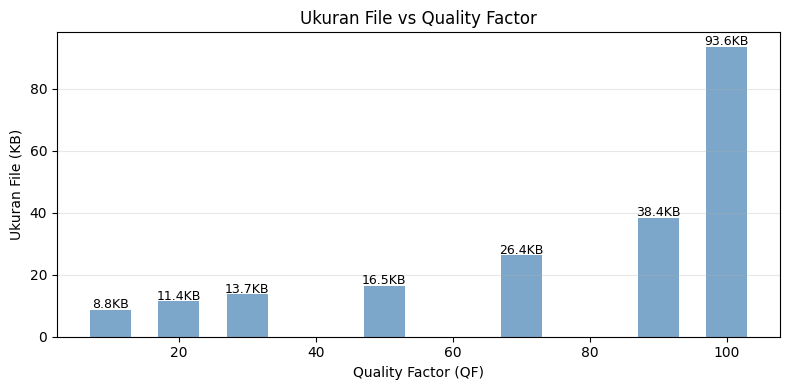

In [6]:
qf_list = [10, 20, 30, 50, 70, 90, 100]
file_sizes = []
original_size = os.path.getsize('wajah_watermarked.png')

print(f'{"QF":<6} {"Ukuran File":<15} {"Rasio Kompresi"}')
print('-' * 40)

for qf in qf_list:
    path = f'wajah_qf{qf}.jpg'
    img_wm_pil.save(path, 'JPEG', quality=qf)
    size = os.path.getsize(path)
    file_sizes.append(size)
    ratio = original_size / size
    print(f'QF={qf:<4} {size/1024:.1f} KB          {ratio:.1f}x lebih kecil')

fig, axes = plt.subplots(1, 7, figsize=(24, 4))
fig.suptitle('Hasil Kompresi JPEG per Quality Factor', fontsize=13, fontweight='bold')

for i, qf in enumerate(qf_list):
    img_qf = np.array(Image.open(f'wajah_qf{qf}.jpg').convert('L'))
    axes[i].imshow(img_qf, cmap='gray')
    axes[i].set_title(f'QF={qf}\n{file_sizes[i]/1024:.1f} KB')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(qf_list, [s/1024 for s in file_sizes], color='steelblue', alpha=0.7, width=6)
plt.title('Ukuran File vs Quality Factor')
plt.xlabel('Quality Factor (QF)')
plt.ylabel('Ukuran File (KB)')
plt.grid(True, alpha=0.3, axis='y')
for qf, size in zip(qf_list, file_sizes):
    plt.text(qf, size/1024 + 0.5, f'{size/1024:.1f}KB', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Cell 7 - Ekstraksi Watermark & Perhitungan BER

===== HASIL EVALUASI =====
QF     BER        Keterangan
----------------------------------------
QF=10   BER=0.4988   Tidak bisa diekstrak
QF=20   BER=0.4988   Tidak bisa diekstrak
QF=30   BER=0.4988   Tidak bisa diekstrak
QF=50   BER=0.5012   Tidak bisa diekstrak
QF=70   BER=0.5012   Tidak bisa diekstrak
QF=90   BER=0.4397   Tidak bisa diekstrak
QF=100  BER=0.0581   Bisa diekstrak


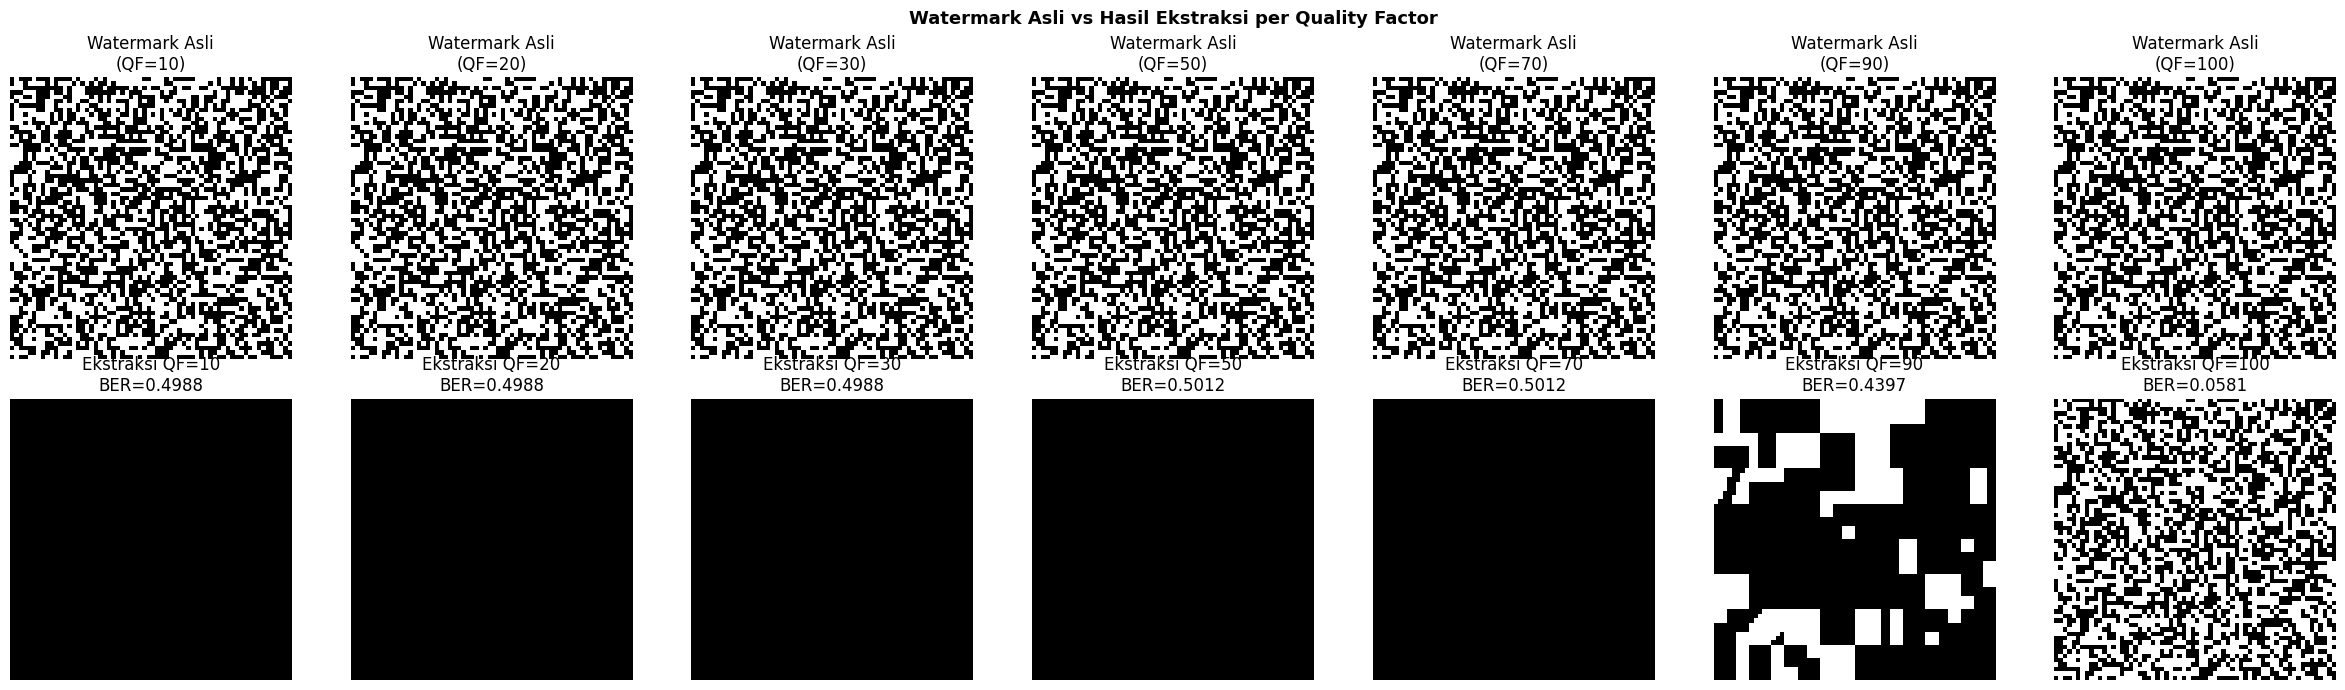

In [7]:
def extract_watermark(image_path, wm_shape=(64, 64)):
    img = Image.open(image_path).convert('L')
    arr = np.array(img)
    return arr[:wm_shape[0], :wm_shape[1]] & 1

def ber(original_wm, extracted_wm):
    errors = np.sum(original_wm != extracted_wm)
    return errors / original_wm.size

print('===== HASIL EVALUASI =====')
print(f'{"QF":<6} {"BER":<10} {"Keterangan"}')
print('-' * 40)

ber_values = []
for qf in qf_list:
    extracted = extract_watermark(f'wajah_qf{qf}.jpg')
    error_rate = ber(watermark, extracted)
    ber_values.append(error_rate)
    status = 'Bisa diekstrak' if error_rate < 0.1 else 'Tidak bisa diekstrak'
    print(f'QF={qf:<4} BER={error_rate:.4f}   {status}')

fig, axes = plt.subplots(2, 7, figsize=(24, 7))
fig.suptitle('Watermark Asli vs Hasil Ekstraksi per Quality Factor', fontsize=13, fontweight='bold')

for i, qf in enumerate(qf_list):
    axes[0, i].imshow(watermark, cmap='gray')
    axes[0, i].set_title(f'Watermark Asli\n(QF={qf})')
    axes[0, i].axis('off')

for i, qf in enumerate(qf_list):
    extracted = extract_watermark(f'wajah_qf{qf}.jpg')
    axes[1, i].imshow(extracted, cmap='gray')
    axes[1, i].set_title(f'Ekstraksi QF={qf}\nBER={ber(watermark, extracted):.4f}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('hasil_watermarking.png', dpi=150)
plt.show()

## Cell 8 - Grafik BER vs Quality Factor

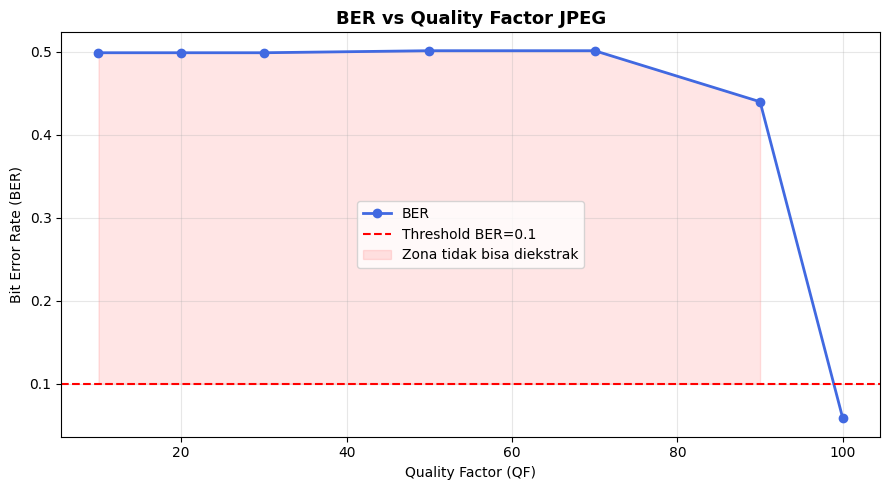

Kesimpulan:
  QF=10   -> BER=0.4988 -> Tidak bisa diekstrak
  QF=20   -> BER=0.4988 -> Tidak bisa diekstrak
  QF=30   -> BER=0.4988 -> Tidak bisa diekstrak
  QF=50   -> BER=0.5012 -> Tidak bisa diekstrak
  QF=70   -> BER=0.5012 -> Tidak bisa diekstrak
  QF=90   -> BER=0.4397 -> Tidak bisa diekstrak
  QF=100  -> BER=0.0581 -> Bisa diekstrak


In [8]:
plt.figure(figsize=(9, 5))
plt.plot(qf_list, ber_values, marker='o', color='royalblue', linewidth=2, label='BER')
plt.axhline(y=0.1, color='red', linestyle='--', label='Threshold BER=0.1')
plt.fill_between(qf_list, ber_values, 0.1,
                 where=[b > 0.1 for b in ber_values],
                 alpha=0.1, color='red', label='Zona tidak bisa diekstrak')
plt.title('BER vs Quality Factor JPEG', fontsize=13, fontweight='bold')
plt.xlabel('Quality Factor (QF)')
plt.ylabel('Bit Error Rate (BER)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafik_ber.png', dpi=150)
plt.show()

print('Kesimpulan:')
for qf, bv in zip(qf_list, ber_values):
    status = 'Bisa diekstrak' if bv < 0.1 else 'Tidak bisa diekstrak'
    print(f'  QF={qf:<4} -> BER={bv:.4f} -> {status}')

## Cell 9 - Download Semua Hasil

In [ ]:
for f in ['visualisasi_dct.png', 'wajah_watermarked.png', 'hasil_watermarking.png', 'grafik_ber.png']:
    files.download(f)
    print(f'Downloaded: {f}')